# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

## Data Curation and Imputation

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
sns.set_context('talk')

We will work with the `melb_data` data base presented in the following cell. It's a data base that presents the different sold properties in Melbourne, Australia.

In [64]:
# Cargamos los datos
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


 Variables:

- `Suburb`: Suburb of the property.

- `Address`: Adress of the propiedad.

- `Rooms`: Number of rooms.

- `Price`: Price of sale.

- `Method`: Method of sale (for example, auction, private sale). S - property sold; SP - property sold prior; PI - property passed in; PN - sold prior not disclosed; SN - sold not disclosed; NB - no bid; VB - vendor bid; W - withdrawn prior to auction; SA - sold after auction; SS - sold after auction price not disclosed. N/A - price or highest bid not available.

- `Type`: Type of property (house, unit, department). br - bedroom(s); h - house,cottage,villa, semi,terrace; u - unit, duplex; t - townhouse; dev site - development site; o res - other residential.

- `SellerG`: Name og the agente or group sell.

- `Date`: Date of sale.

- `Distance`: Distancie from Melbourne central district(in km).

- `Regionname`: General region of location. (West, North West, North, North east …etc)

- `Propertycount`: Total number of properties registered in the suburb. Indicator of the size of the local inmobiliary market.

- `Bedroom2`: Number of bedrooms extracted from an alternative source by *web scraping*. It can differ from the main variable of rooms (`Rooms`).

- `Bathroom`: Number of bathrooms in the property. Important factor to estimate the value and comodity of the property.

- `Car`: Number of spaces available for parking.

- `Landsize`: Size of the land (in squared meters). Relevant for properties with gardens, and it can impact strongly on the price.

- `BuildingArea`: Area builded in the property (in squared meter). Living area.

- `CouncilArea`: Name of the council of the area. It can relate to regulations, public services and municipal taxes.


The objective of this project is to practice the curation of dataframes.

In [65]:
melb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

## 1. Filtering data

Las variables `BuildingArea` y `YearBuilt` son las que tienen menos cantidad de datos, decidimos eliminarlas para concentrarnos en las demás variables, luegos estas variables serán imputadas y se explicara más adelante.

In [66]:
melb_df_c = melb_df.drop(columns=["YearBuilt", "BuildingArea"])

cols_conserved = ["Suburb", "Rooms", "Price", "Distance", "Postcode",
                    "Bedroom2", "Bathroom", "Car", "Landsize", "CouncilArea",
                    "Lattitude", "Longtitude", "Regionname", "Propertycount",
                    "Date", "Type", "Method", "SellerG", "Address"]

melb_df_c = melb_df[cols_conserved].copy()

From this columns let's analize the missing data.

In [67]:
missing = melb_df_c.isna().sum()
missing_pct = (melb_df_c.isna().mean() * 100).round(2)

print(pd.concat([missing, missing_pct], axis=1, keys=["count", "percentage"]))

               count  percentage
Suburb             0        0.00
Rooms              0        0.00
Price              0        0.00
Distance           0        0.00
Postcode           0        0.00
Bedroom2           0        0.00
Bathroom           0        0.00
Car               62        0.46
Landsize           0        0.00
CouncilArea     1369       10.08
Lattitude          0        0.00
Longtitude         0        0.00
Regionname         0        0.00
Propertycount      0        0.00
Date               0        0.00
Type               0        0.00
Method             0        0.00
SellerG            0        0.00
Address            0        0.00


The variable `CouncilArea` has around 10% of missing data. Taking into account that this category doesn't provide adittional information apart from other variables we decide to eliminate it.


In [68]:
melb_df_c = melb_df_c.drop(columns=["CouncilArea"])

On the other side, the variable `Car` has a total of 62 missing data, which represents around 0.46% of the total data.Because it's not that many values it makes no sense to impute them so we decide to delete this rows.

In [69]:
melb_df_c = melb_df_c.dropna(subset=["Car"])

In [70]:
# Verification
print(melb_df_c.isna().sum())
print(f"Filas finales: {len(melb_df_c)}")

Suburb           0
Rooms            0
Price            0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
Date             0
Type             0
Method           0
SellerG          0
Address          0
dtype: int64
Filas finales: 13518


Now let's analize the cero values of the dataset.

In [71]:
cols = melb_df_c[melb_df_c == 0].count(axis=0) #rows axis=0, columns axis=1

cols[cols > 0] #print just >0

Distance       6
Bedroom2      16
Bathroom      34
Car         1026
Landsize    1939
dtype: int64

- The variable `Distance` represent de distance from the central district so it makes sense that some values are cero. Furthermore we just have 6 values so we decide to **keep them**.

- In the case of `Car`, it's possible to have a property without a cochera, so we keep those rows.

- The cero values in the variable `Bathroom` make nop sense y there are few in comparison with the size of the dataset therefore we decide to eliminate them. Furthermore the values that are higher for the variable `Bathroom` than for `Rooms` were also deleted because they make no sense.


In [72]:
pd.crosstab(melb_df_c.Bathroom, melb_df_c.Rooms)

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.0,1,19,11,3,0,0,0,0,0
1.0,671,3093,3233,451,17,2,0,0,0
2.0,6,502,2447,1718,260,20,3,2,0
3.0,0,8,153,468,244,35,5,2,1
4.0,0,0,5,41,47,9,2,2,0
5.0,0,0,1,2,25,0,0,0,0
6.0,0,0,2,0,2,1,0,0,0
7.0,0,0,0,0,1,0,0,1,0
8.0,0,0,0,1,0,0,0,1,0


In [73]:
melb_df_c = melb_df_c[
    (melb_df_c['Bathroom'] <= melb_df_c['Rooms'] )
]
melb_df_c = melb_df_c[melb_df_c['Bathroom'] != 0]

- For the variable `Landsize` we trnasform the cero values to `Nan` so we imput them later.


In [74]:
melb_df_c.loc[melb_df_c.Landsize<1,'Landsize']=pd.NA

Now let's analize the variable `Bedroom2`.

In [75]:
pd.crosstab(melb_df_c.Bedroom2, melb_df_c.Rooms)

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.0,0,2,5,3,0,0,0,0,0
1.0,656,21,5,2,0,0,0,0,0
2.0,14,3493,162,19,1,0,0,0,0
3.0,1,72,5584,173,18,1,0,0,0
4.0,0,6,72,2466,42,4,0,1,0
5.0,0,1,4,15,528,2,2,0,0
6.0,0,0,0,0,2,59,0,2,0
7.0,0,0,0,0,1,1,8,0,0
8.0,0,0,0,0,1,0,0,4,0


If we compare the variable `Bedrooms2` with `Rooms` we can see cases where there are more bedrooms than room which makes no sense. Furthermore, the variable `Bedroom2` comes from other source than the original wich can introduce bias. Therefore we decide to eliminate `Bedroom2`.

In [76]:
melb_df_c = melb_df_c.drop(['Bedroom2'], axis=1)

In [77]:
melb_df_c.info()

<class 'pandas.DataFrame'>
Index: 13456 entries, 0 to 13579
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13456 non-null  str    
 1   Rooms          13456 non-null  int64  
 2   Price          13456 non-null  float64
 3   Distance       13456 non-null  float64
 4   Postcode       13456 non-null  float64
 5   Bathroom       13456 non-null  float64
 6   Car            13456 non-null  float64
 7   Landsize       11539 non-null  float64
 8   Lattitude      13456 non-null  float64
 9   Longtitude     13456 non-null  float64
 10  Regionname     13456 non-null  str    
 11  Propertycount  13456 non-null  float64
 12  Date           13456 non-null  str    
 13  Type           13456 non-null  str    
 14  Method         13456 non-null  str    
 15  SellerG        13456 non-null  str    
 16  Address        13456 non-null  str    
dtypes: float64(9), int64(1), str(7)
memory usage: 1.8 MB


## 2. Numeric Variables

Let's choose the numeric categories.

In [78]:
melb_num = melb_df_c.select_dtypes(include='number')
melb_num.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount
count,13456.000000,1.345600e+04,13456.000000,13456.000000,13456.000000,13456.000000,11539.000000,13456.000000,13456.000000,13456.000000
mean,2.941662,1.074193e+06,10.165064,3105.126040,1.534260,1.613407,651.594246,-37.809064,144.995264,7454.628493
std,0.955930,6.383880e+05,5.862542,90.633621,0.676747,0.958559,4320.362646,0.079368,0.104118,4383.273753
min,1.000000,8.500000e+04,0.000000,3000.000000,1.000000,0.000000,1.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.200000,3044.000000,1.000000,1.000000,271.500000,-37.856912,144.929190,4380.000000
50%,3.000000,9.007500e+05,9.200000,3084.000000,1.000000,2.000000,534.000000,-37.802175,145.000275,6567.000000
75%,3.000000,1.327625e+06,13.000000,3148.000000,2.000000,2.000000,676.000000,-37.756100,145.058645,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,8.000000,10.000000,433014.000000,-37.408530,145.526350,21650.000000


In [79]:
print(melb_num.dtypes)

Rooms              int64
Price            float64
Distance         float64
Postcode         float64
Bathroom         float64
Car              float64
Landsize         float64
Lattitude        float64
Longtitude       float64
Propertycount    float64
dtype: object


The variable `Postcode` is numeric but if we try to do stadistics on this variable it won't give relevant information, therefore we decide to change to a categoric variable.

In [80]:
melb_df_c['Postcode'] = melb_df_c['Postcode'].astype(str)
melb_num = melb_num.drop(columns=["Postcode"])

Now let's create a numeric matrix.

In [81]:
columns_num = melb_num.columns.tolist()
array_num = melb_num.to_numpy()
print(array_num[:3])

[[ 2.000000e+00  1.480000e+06  2.500000e+00  1.000000e+00  1.000000e+00
   2.020000e+02 -3.779960e+01  1.449984e+02  4.019000e+03]
 [ 2.000000e+00  1.035000e+06  2.500000e+00  1.000000e+00  0.000000e+00
   1.560000e+02 -3.780790e+01  1.449934e+02  4.019000e+03]
 [ 3.000000e+00  1.465000e+06  2.500000e+00  2.000000e+00  0.000000e+00
   1.340000e+02 -3.780930e+01  1.449944e+02  4.019000e+03]]


## 3. Categoric Variables

Let's focus on the categoric variables.

In [82]:
melb_cate = melb_df_c.select_dtypes(include='object')
print(melb_cate.dtypes)

Suburb        str
Postcode      str
Regionname    str
Date          str
Type          str
Method        str
SellerG       str
Address       str
dtype: object


C:\Users\delfi\AppData\Local\Temp\ipykernel_24052\2086409656.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  melb_cate = melb_df_c.select_dtypes(include='object')


The variable `Date` has numeric values but it's classified as categoric. Therefore we decide to add it to the numeric matrix and split it in two columns, one with the year and the othe whit the month.

In [83]:
melb_cate["Date"] = pd.to_datetime(melb_cate["Date"], dayfirst=True)
melb_cate["Year"] = melb_cate["Date"].dt.year
melb_cate["Month"] = melb_cate["Date"].dt.month

matrix_num = np.hstack((array_num, melb_cate[['Year', 'Month']].values))
col_matrix_num = columns_num + ['Year', 'Month']

print(f"Categoric columns: {list(melb_cate.columns)}")
print(f"Numeric columns: {list(col_matrix_num)}")

Categoric columns: ['Suburb', 'Postcode', 'Regionname', 'Date', 'Type', 'Method', 'SellerG', 'Address', 'Year', 'Month']
Numeric columns: ['Rooms', 'Price', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount', 'Year', 'Month']


Let's see the unique categories of each variable so we can do a One-Hot encoding later.

In [84]:
for col in ["Type", "Method", "Regionname", "SellerG", "Suburb", "Address", "Postcode"]:
    print(f"{col}: {melb_df[col].nunique()} unique categories")

Type: 3 unique categories
Method: 5 unique categories
Regionname: 8 unique categories
SellerG: 268 unique categories
Suburb: 314 unique categories
Address: 13378 unique categories
Postcode: 198 unique categories


The variable `Postcode` doesn't give additional information from the other variables so we decide to eliminate it.

The variable `Adress` has too many unique categories so it's not convenient to use a One-Hot Encoding, so we decide to eliminate it too. We also eliminate  the variables `Date`, `Year`, `Month` from the categoric variable because remember we changed them to numeric.

In [85]:
melb_cate = melb_cate.drop(columns=["Address","Date","Year","Month","Postcode"])
print(f"Categoric columns: {list(melb_cate.columns)}")

Categoric columns: ['Suburb', 'Regionname', 'Type', 'Method', 'SellerG']


For the rest of the variable with less than 10 unique categories we decide to aply the One-Hot Encoding.

For the variables `SellerG` and `Suburb` with more than 200 unique categories, we decide to reduce that amount by studying the frequency of every category. The categories with less than 1% frequency are grouped in a new category `Other`.

In [86]:
columns_reduce = ['Suburb', 'SellerG']
threshold = 0.01 

for col in columns_reduce:
    
    frequencies = melb_cate[col].value_counts(normalize=True)

    
    important_categories = frequencies[frequencies >= threshold].index

    
    melb_cate[col] = melb_cate[col].where(melb_cate[col].isin(important_categories), 'Other')

    print(f"{col} after reducing categories: {melb_cate[col].nunique()} categories unique")

Suburb after reducing categories: 26 categories unique
SellerG after reducing categories: 24 categories unique


We proceed with the One-Hot Encoding.

In [87]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction import DictVectorizer   

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [88]:
encoded_types = encoder.fit_transform(melb_cate[['Type', 'Method', 'Regionname','SellerG', 'Suburb']])
encoded_types[:5]

array([[1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1

In [89]:
matrix_cate = encoded_types
col_cate = encoder.get_feature_names_out(['Type', 'Method', 'Regionname', 'SellerG', 'Suburb'])

print(matrix_cate.shape)
print([(i, col) for i, col in enumerate(col_cate)])


(13456, 66)
[(0, 'Type_h'), (1, 'Type_t'), (2, 'Type_u'), (3, 'Method_PI'), (4, 'Method_S'), (5, 'Method_SA'), (6, 'Method_SP'), (7, 'Method_VB'), (8, 'Regionname_Eastern Metropolitan'), (9, 'Regionname_Eastern Victoria'), (10, 'Regionname_Northern Metropolitan'), (11, 'Regionname_Northern Victoria'), (12, 'Regionname_South-Eastern Metropolitan'), (13, 'Regionname_Southern Metropolitan'), (14, 'Regionname_Western Metropolitan'), (15, 'Regionname_Western Victoria'), (16, 'SellerG_Barry'), (17, 'SellerG_Biggin'), (18, 'SellerG_Brad'), (19, 'SellerG_Buxton'), (20, 'SellerG_Fletchers'), (21, 'SellerG_Gary'), (22, 'SellerG_Greg'), (23, 'SellerG_Harcourts'), (24, 'SellerG_Hodges'), (25, 'SellerG_Jas'), (26, 'SellerG_Jellis'), (27, 'SellerG_Marshall'), (28, 'SellerG_McGrath'), (29, 'SellerG_Miles'), (30, 'SellerG_Nelson'), (31, 'SellerG_Noel'), (32, 'SellerG_Other'), (33, 'SellerG_RT'), (34, 'SellerG_Ray'), (35, 'SellerG_Stockdale'), (36, 'SellerG_Sweeney'), (37, 'SellerG_Woodards'), (38, 'Se

## 5. Concatenar both matix

In [90]:
final_matrix = np.hstack((matrix_num, matrix_cate))

print(f"Format of numeric matrix: {matrix_num.shape}")
print(f"Format of categorical matrix: {matrix_cate.shape}")

print(f"Format of final matrix: {final_matrix.shape}")

col_matrix_final = col_matrix_num + list(col_cate)
print(f"Columns of final matrix: {len(col_matrix_final)}")

Format of numeric matrix: (13456, 11)
Format of categorical matrix: (13456, 66)
Format of final matrix: (13456, 77)
Columns of final matrix: 77


## 6. Imputation

Now that we cleaned most of the columns let's focus on the ones we deleted before we started, `BuildingArea` and `YearBuilt`. These variables are important but they have lot of `Nan` values, so the course of action will be to impute them. 

Let's add them anf filter them.

In [91]:
extra_cols = melb_df.loc[melb_df_c.index, ['YearBuilt', 'BuildingArea']].to_numpy()
print(f"Format of added columns: {extra_cols.shape}")  

matrix_imp = np.hstack([matrix_num, extra_cols]) 
print(f"Format of matrix to impute: {matrix_imp.shape}")  


col_matrix_imp = col_matrix_num + ['YearBuilt', 'BuildingArea']

Format of added columns: (13456, 2)
Format of matrix to impute: (13456, 13)


In [92]:
for i, col in enumerate(col_matrix_imp):
    print(f"{i}: {col}")

0: Rooms
1: Price
2: Distance
3: Bathroom
4: Car
5: Landsize
6: Lattitude
7: Longtitude
8: Propertycount
9: Year
10: Month
11: YearBuilt
12: BuildingArea


In [93]:
idx_building = list(col_matrix_imp).index('BuildingArea')
idx_year = list(col_matrix_imp).index('YearBuilt')

#Filter with the quantile
q99 = np.nanpercentile(matrix_imp[:, idx_building], 99)  
q01 = np.nanpercentile(matrix_imp[:, idx_year], 1)     


mask_building = (matrix_imp[:, idx_building] < q99) | np.isnan(matrix_imp[:, idx_building])
mask_year     = (matrix_imp[:, idx_year] > q01) | np.isnan(matrix_imp[:, idx_year])

# Combine both masks
matrix_imp_clean = matrix_imp[mask_building & mask_year]
print(col_matrix_imp)
print(f"Format numerical matrix numerica after cleaning outliers: {matrix_imp_clean.shape}")

['Rooms', 'Price', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount', 'Year', 'Month', 'YearBuilt', 'BuildingArea']
Format numerical matrix numerica after cleaning outliers: (13290, 13)


In [94]:
mask_final = mask_building & mask_year

matrix_imp_clean = matrix_imp[mask_final]
matrix_cate_clean = matrix_cate[mask_final]

print(f"Format matrix after cleaning outliers: {matrix_imp_clean.shape}")
print(f"Format categorical matrix: {matrix_cate_clean.shape}")

Format matrix after cleaning outliers: (13290, 13)
Format categorical matrix: (13290, 66)


Let's do scaling and imputing. We are only gonna impute the variables `YearBuilt`, `BuildingArea` and `Landsize`.

In [95]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

In [96]:
for i, col in enumerate(col_matrix_imp):
    print(f"{i}: {col}")

0: Rooms
1: Price
2: Distance
3: Bathroom
4: Car
5: Landsize
6: Lattitude
7: Longtitude
8: Propertycount
9: Year
10: Month
11: YearBuilt
12: BuildingArea


In [97]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

matrix_scaled = scaler.fit_transform(matrix_imp_clean)

# Impute with KNN
imputer_knn = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=5),
    max_iter=20,
    random_state=42,
    tol=10e-2
)
matrix_imput_knn = imputer_knn.fit_transform(matrix_scaled)


matrix_imput_knn = scaler.inverse_transform(matrix_imput_knn)

In [98]:
matrix_final_imp = np.hstack([matrix_imput_knn, matrix_cate_clean])
col_matrix_final_imp = col_matrix_imp + list(col_cate)
print(f"Format final imputed matrix: {matrix_final_imp.shape}")

Format final imputed matrix: (13290, 79)


We want to compare with simple imputation.

In [99]:
from sklearn.impute import SimpleImputer

imputer_simple = SimpleImputer(strategy='median')
matrix_imput_simple = imputer_simple.fit_transform(matrix_imp_clean)


Let's compare visually.

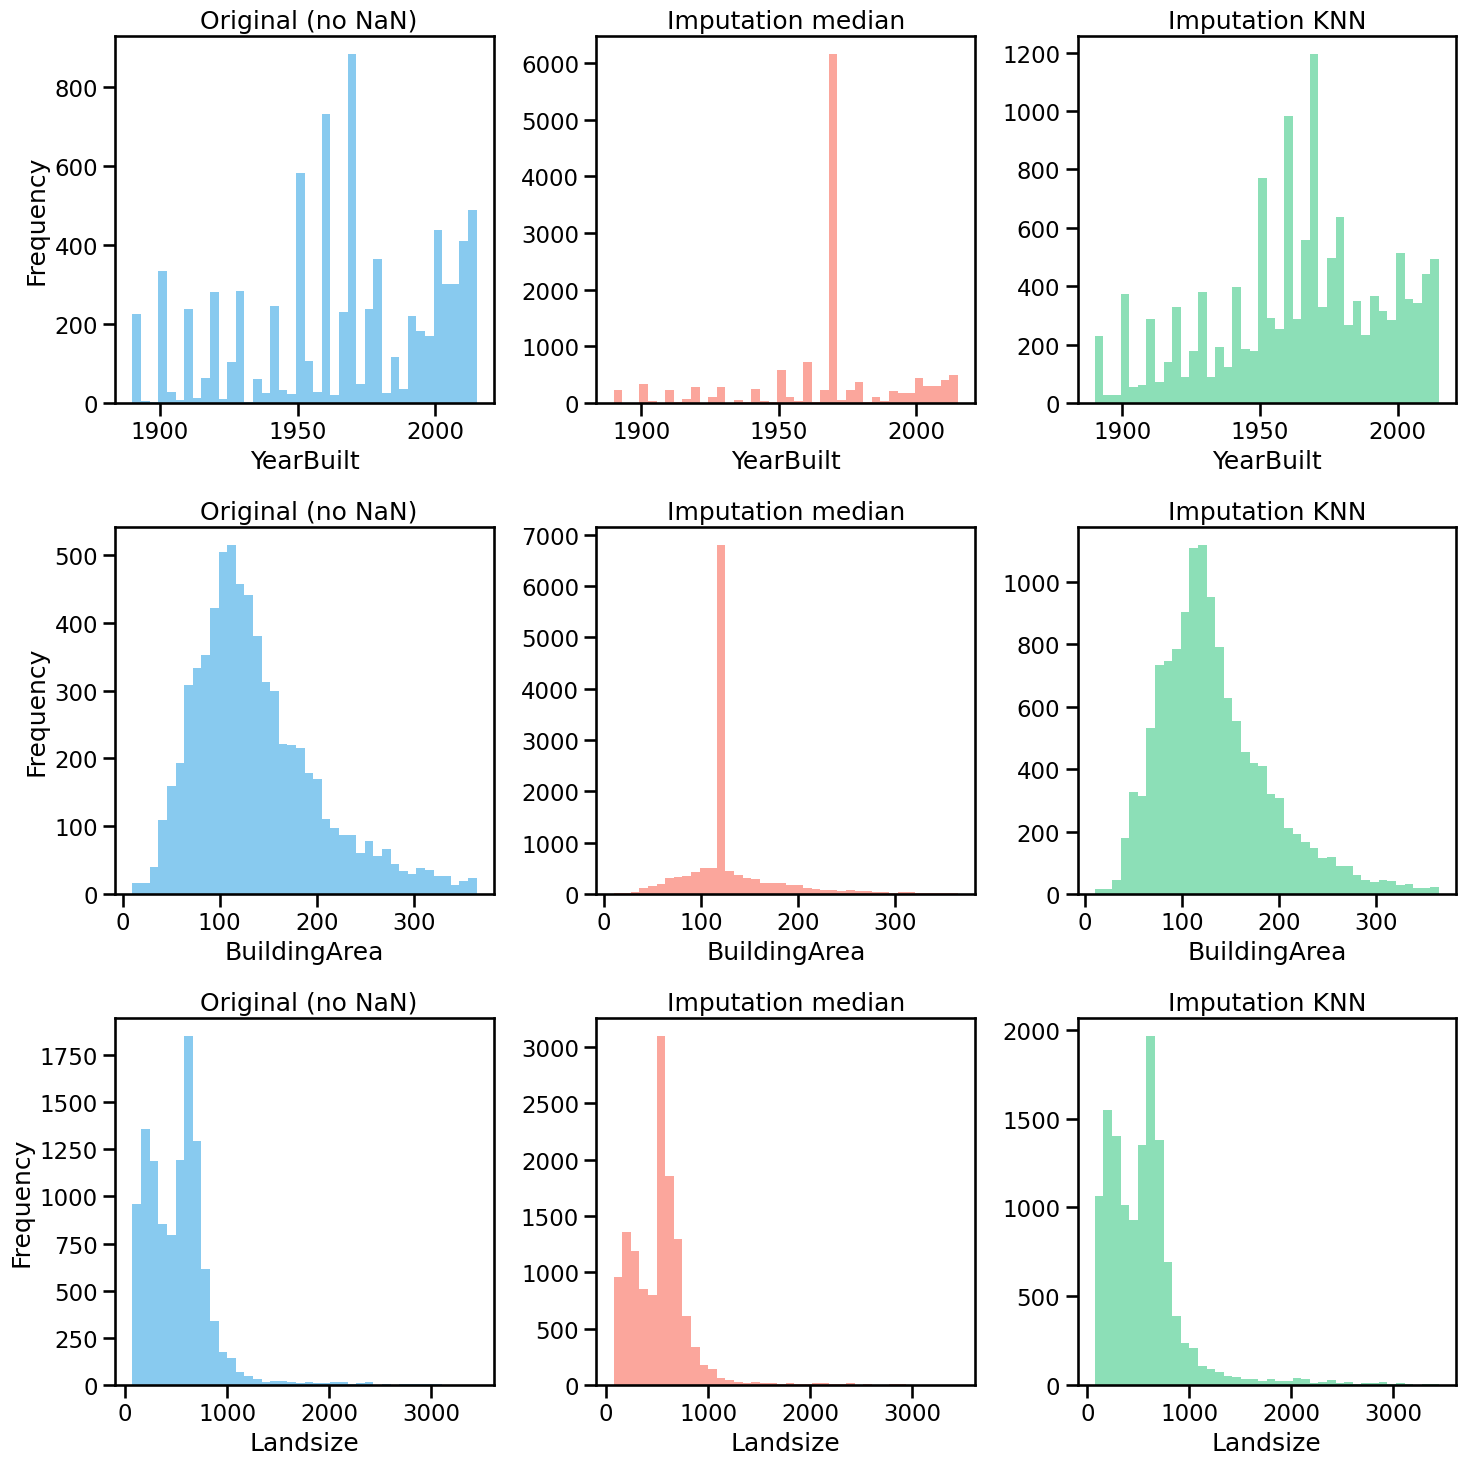

In [100]:

idx_year  = col_matrix_imp.index('YearBuilt')
idx_build = col_matrix_imp.index('BuildingArea')
idx_landsize  = col_matrix_imp.index('Landsize')


fig, axes = plt.subplots(3, 3, figsize=(15, 15))

variables = [
    (idx_year,     'YearBuilt'),
    (idx_build,    'BuildingArea'),
    (idx_landsize, 'Landsize'),
]

for row, (idx, name) in enumerate(variables):

    # Original Data
    original = matrix_imp_clean[:, idx]
    no_nan  = original[~np.isnan(original)]

    # KNN 
    knn_vals = matrix_imput_knn[:, idx]

    # Simple imputation
    simple_vals = matrix_imput_simple[:, idx]

    # ──  ──
    x_max = np.nanpercentile(original, 99)
    x_min = np.nanpercentile(original, 1)

    # 
    no_nan_plot    = no_nan[(no_nan >= x_min)     & (no_nan <= x_max)]
    knn_plot        = knn_vals[(knn_vals >= x_min)   & (knn_vals <= x_max)]
    simple_plot     = simple_vals[(simple_vals >= x_min) & (simple_vals <= x_max)]

    # ── Original (no NaN) ──
    axes[row, 0].hist(no_nan_plot, bins=40, color='#56B4E9', alpha=0.7)
    axes[row, 0].set_title(' Original (no NaN)')
    axes[row, 0].set_xlabel(name)
    axes[row, 0].set_ylabel('Frequency')

    # ── Imputation median ──
    axes[row, 1].hist(simple_plot, bins=40, color='salmon', alpha=0.7)
    axes[row, 1].set_title('Imputation median')
    axes[row, 1].set_xlabel(name)

    # ── Imputation KNN ──
    axes[row, 2].hist(knn_plot, bins=40, color="#5CD299", alpha=0.7)
    axes[row, 2].set_title('Imputation KNN')
    axes[row, 2].set_xlabel(name)


plt.tight_layout()
plt.savefig('Imputation.pdf', dpi=300, bbox_inches='tight')
plt.show()


We can observe that the cases that had lot of `Nan`, the imputation KNN mantains the original distribution whereas the median imputation modifies. For the cases `Car` and `Bathroom`, because we have lots of `Nan` both imputation give similar results.

## 7. Reduce dimensionality

Let's apply PCA, but first we must standarice the data again.

In [101]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Estandarizamos primero
scaler_pca = StandardScaler()
matrix_scaled = scaler_pca.fit_transform(matrix_final_imp)

Number of components: 20
Shape original matrix: (13290, 79)
Shape after PCA: (13290, 20)

Variance explained by PC1: 5.47%
Variance explained by PC2: 4.43%
Variance accumulated (20 PCs): 45.32%


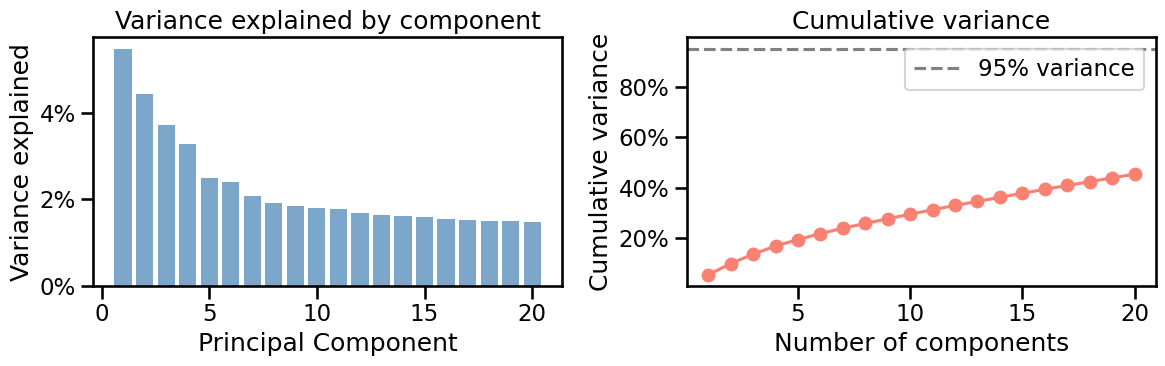

In [102]:
# ──  PCA ────────────────────────────────────────────────────

# Define n principal components
n = min(20, matrix_final_imp.shape[0])
print(f"Number of components: {n}")
print(f"Shape original matrix: {matrix_final_imp.shape}")

# Apply PCA
pca = PCA(n_components=n, random_state=42)
matrix_pca = pca.fit_transform(matrix_scaled)

print(f"Shape after PCA: {matrix_pca.shape}")

# Variance explained
variance_explained = pca.explained_variance_ratio_
variance_acumulatted = np.cumsum(variance_explained)

print(f"\nVariance explained by PC1: {variance_explained[0]:.2%}")
print(f"Variance explained by PC2: {variance_explained[1]:.2%}")
print(f"Variance accumulated ({n} PCs): {variance_acumulatted[-1]:.2%}")

# ── Scree plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, n+1), variance_explained, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance explained')
axes[0].set_title('Variance explained by component')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[1].plot(range(1, n+1), variance_acumulatted, marker='o', color='salmon')
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance')
axes[1].set_title('Cumulative variance')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend()

plt.tight_layout()
plt.show()


Now let's add principal components

In [103]:
# ── Add PC1 and PC2 to the matrix ──────────────────────────
pc1 = matrix_pca[:, 0].reshape(-1, 1)
pc2 = matrix_pca[:, 1].reshape(-1, 1)

matrix_final_with_pca = np.hstack([matrix_final_imp, pc1, pc2])

print(f"\nShape matrix original:      {matrix_final_imp.shape}")
print(f"Shape matrix con PC1 y PC2: {matrix_final_with_pca.shape}")



Shape matrix original:      (13290, 79)
Shape matrix con PC1 y PC2: (13290, 81)


So we can use these components let's see how well it predicts the behaviour of some variable like `Rooms`.

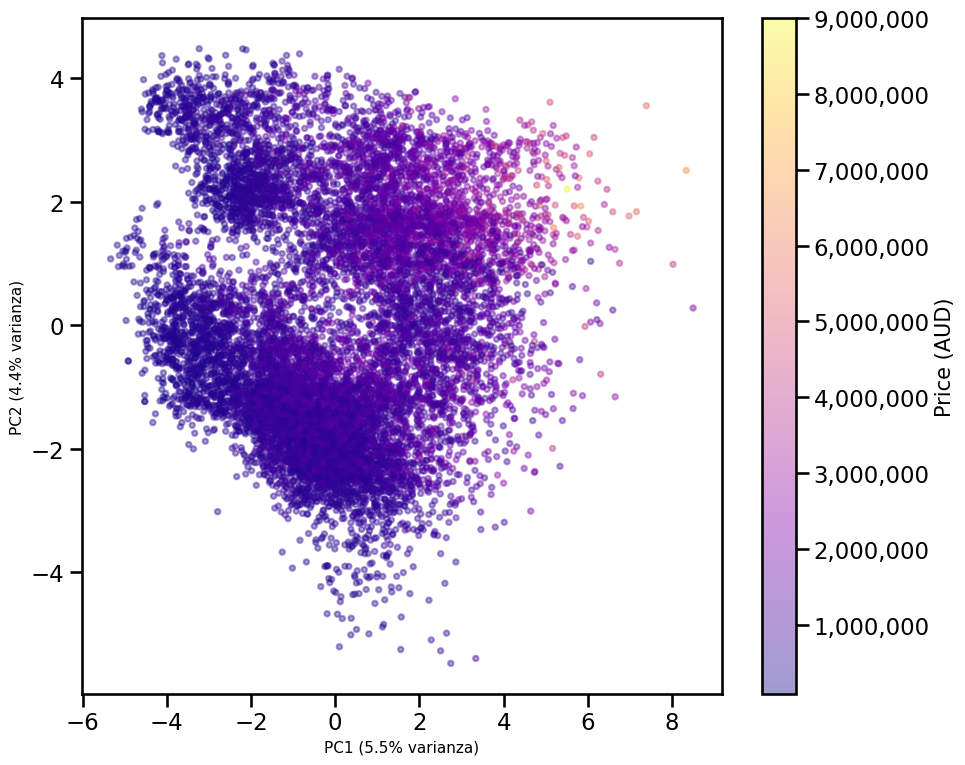

In [104]:

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    matrix_pca[:, 0],
    matrix_pca[:, 1],
    c=matrix_final_imp[:,col_matrix_imp.index('Price')],  #.values[:matrix_pca.shape[0]],
    cmap='plasma',
    alpha=0.4,
    s=15
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
cbar.set_label('Price (AUD)', fontsize=15, )

ax.set_xlabel(f'PC1 ({variance_explained[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({variance_explained[1]:.1%} varianza)', fontsize=11)
#ax.set_title('Proyección PCA coloreada por Price', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('PCA_Price.pdf', dpi=300, bbox_inches='tight')
plt.show()

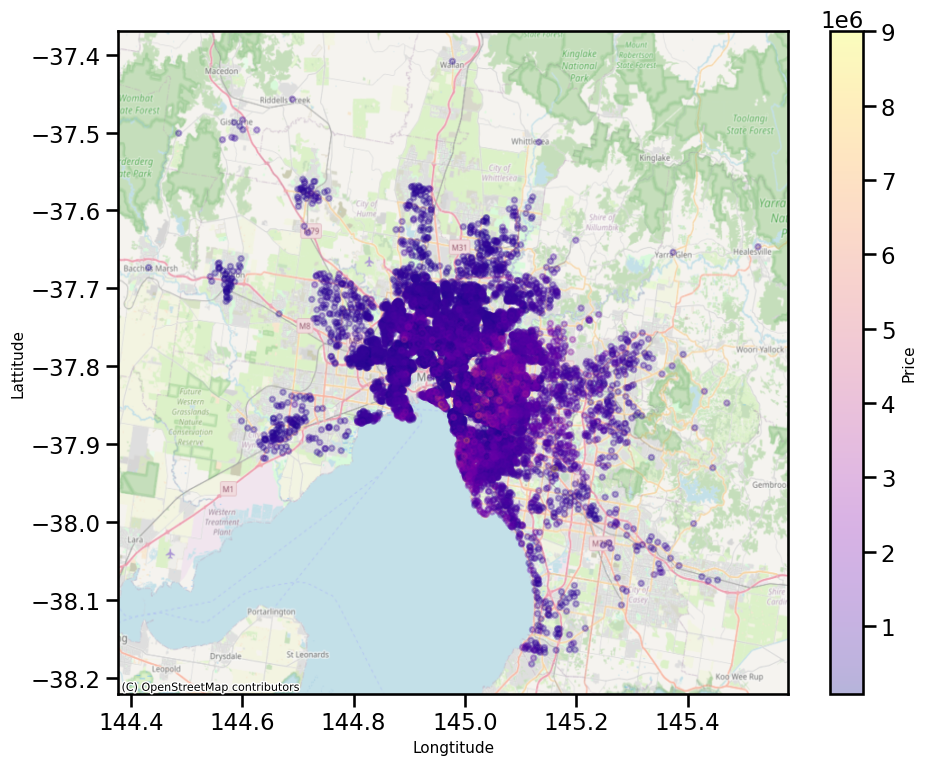

In [105]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 8))

#mask_price = matriz_imputada_knn[:, col_matriz_imp.index('Price')] >= 5_000_000

scatter =ax.scatter(
    y = matrix_final_with_pca[:, col_matrix_imp.index('Lattitude')],
    x = matrix_final_with_pca[:, col_matrix_imp.index('Longtitude')],
    c=matrix_final_with_pca[:, col_matrix_imp.index('Price')],
    cmap='plasma',
    alpha=0.3,
    s=15
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Price', fontsize=11)
ax.set_xlabel('Longtitude', fontsize=11)
ax.set_ylabel('Lattitude', fontsize=11)

#ax.set_ylim(-38,-37.6)
#ax.set_xlim(144.5,145.5)

ctx.add_basemap(ax, alpha=0.7,crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)
plt.tight_layout()
plt.show()

## 8. Composition of result

Let's remember we have a matrix and we wanna change it ot a dataframe so we v=can work with it in the future

In [106]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

# Names of the numeric columns original
names_num = melb_num.columns.tolist()

# Names of the date columns
names_fecha = ['Year', 'Month']

# Names of the columns from the OneHotEncoder
names_cate = encoder.get_feature_names_out(['Type', 'Method', 'Regionname', 'SellerG', 'Suburb']).tolist()

# Names of the extra columns and PCA
names_extra = ['YearBuilt', 'BuildingArea']
names_pca = ['PC1', 'PC2']

#Combine of the names of the list
names_columnas_final = names_num + names_fecha + names_cate + names_extra + names_pca

# Create the final DataFrame
df_processed_final = pd.DataFrame(data=matrix_final_with_pca, columns=names_columnas_final)

#  Guardar en un archivo CSV
df_processed_final.to_csv('melb_data_processed.csv', index=False)

print(f"Dimensions of the final Dataset: {df_processed_final.shape}")
print("First 5 columns:", df_processed_final.columns[:5].tolist())
print("Last 5 columns:", df_processed_final.columns[-5:].tolist())

print(f"Format of the final dataframe: {df_processed_final.shape}")



Dimensions of the final Dataset: (13290, 81)
First 5 columns: ['Rooms', 'Price', 'Distance', 'Bathroom', 'Car']
Last 5 columns: ['Suburb_Yarraville', 'YearBuilt', 'BuildingArea', 'PC1', 'PC2']
Format of the final dataframe: (13290, 81)


In [107]:
df_processed_final.describe()

,Rooms,Price,Distance,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount,Year,...,Suburb_Reservoir,Suburb_Richmond,Suburb_South Yarra,Suburb_St Kilda,Suburb_Thornbury,Suburb_Yarraville,YearBuilt,BuildingArea,PC1,PC2
count,13290.000000,1.329000e+04,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,...,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,13290.000000,1.329000e+04,1.329000e+04
mean,2.936494,1.065590e+06,10.191242,1.529044,1.612039,690.029345,-37.808911,144.995280,7452.272235,2016.533333,...,0.010760,0.017457,0.026712,0.019413,0.014372,0.011738,0.010459,0.011813,-3.421726e-15,8.639857e-15
std,0.953206,6.233492e+05,5.844011,0.668643,0.955700,4029.415407,0.079441,0.104262,4385.246911,0.498906,...,0.103175,0.130971,0.161246,0.137977,0.119022,0.107709,0.101737,0.108050,2.079011e+00,1.870895e+00
min,1.000000,8.500000e+04,0.000000,1.000000,0.000000,1.000000,-38.182550,144.431810,249.000000,2016.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.331586e+00,-5.471497e+00
25%,2.000000,6.456250e+05,6.200000,1.000000,1.000000,279.000000,-37.857000,144.928562,4380.000000,2016.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.469158e+00,-1.524365e+00
50%,3.000000,9.000000e+05,9.300000,1.000000,2.000000,537.000000,-37.802000,145.000500,6567.000000,2017.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.635162e-02,-3.496406e-01
75%,3.000000,1.320000e+06,13.000000,2.000000,2.000000,697.000000,-37.755600,145.058875,10331.000000,2017.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.423261e+00,1.615535e+00
max,10.000000,9.000000e+06,47.400000,8.000000,10.000000,433014.000000,-37.408530,145.526350,21650.000000,2017.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.498026e+00,4.478605e+00
